# LAB 1 — Notebook 00: Master EDA
## Mobile Money Fraud Detection | PaySim Dataset
**EEF606 — Data-Driven Science and Engineering | University of Buea**

---
### How to use this file
**Run this notebook FIRST.** It cleans the data, engineers features, and saves two files:
- `paysim_clean.csv` → cleaned data with all engineered features
- `paysim_features.csv` → numeric-only model-ready matrix

All other notebooks (`lab1_01_classification.ipynb`, etc.) load those files.

### Dataset
**PaySim** — a synthetic mobile money transaction simulator trained on real transaction logs from a mobile financial service in an African country. Available on Kaggle:
> https://www.kaggle.com/datasets/ealaxi/paysim1

Place the CSV file (`PS_20174392719_1491204439457_log.csv`) in the same folder as this notebook.
If the file is not found, a built-in fallback generator will create a representative sample automatically.

---
## Table of Contents
1. Setup & Data Load
2. Column Understanding
3. Data Quality Audit
4. Class Imbalance Analysis
5. Univariate Analysis
6. Bivariate Analysis
7. Multivariate Analysis
8. Fraud Pattern Deep-Dive
9. Feature Engineering
10. Correlation Analysis
11. EDA Summary
12. Save Artefacts

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Library Imports & Global Configuration
#
# WHY THIS ORDER:
# Standard library → third-party → local. This is PEP8
# convention and makes dependency errors easier to diagnose.
#
# WHY warnings.filterwarnings('ignore'):
# Seaborn and sklearn emit deprecation warnings that clutter
# output without helping understanding. We silence them here
# but NEVER in production code — warnings exist for a reason.
#
# WHY rcParams:
# Setting global plot defaults once means every figure in this
# notebook has a consistent, readable appearance without
# repeating style code in each cell.
# ══════════════════════════════════════════════════════════
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Colour constants ───────────────────────────────────────
C_LEGIT  = '#2196F3'   # blue  — legitimate transactions
C_FRAUD  = '#F44336'   # red   — fraudulent transactions
PALETTE  = {'Legitimate': C_LEGIT, 'Fraud': C_FRAUD}
BICOLORS = [C_LEGIT, C_FRAUD]

print('✅ Libraries loaded')
print(f'   pandas  {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

✅ Libraries loaded
   pandas  2.3.3 | numpy 2.3.5 | seaborn 0.13.2


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Data Load (Kaggle File OR Fallback Generator)
#
# WHY TWO PATHS:
# The Kaggle file has 6.3M rows — ideal for real results.
# But when working offline or testing, we need to run
# the notebook immediately. The fallback generator creates
# a 50,000-row dataset with the SAME schema and realistic
# fraud patterns so code runs identically either way.
#
# WHY nrows=300_000 on the Kaggle file:
# 6.3M rows takes ~4 minutes to process on a laptop. We
# sample 300K rows (still ~840 fraud cases) for EDA speed.
# In the classification notebook we'll use more rows.
# ══════════════════════════════════════════════════════════
KAGGLE_FILE = 'PS_20174392719_1491204439457_log.csv'
SAMPLE_ROWS = 300_000

def generate_fallback_data(n=50_000, seed=42):
    """Create PaySim-schema data when Kaggle CSV is absent."""
    rng = np.random.default_rng(seed)
    tx_types = rng.choice(
        ['PAYMENT','TRANSFER','CASH_OUT','DEBIT','CASH_IN'],
        n, p=[0.35, 0.25, 0.22, 0.10, 0.08])
    amount   = np.abs(rng.exponential(150_000, n)).round(2)
    oldOrig  = np.abs(rng.exponential(200_000, n)).round(2)
    newOrig  = np.maximum(0, oldOrig - amount * rng.uniform(0.5,1.5,n)).round(2)
    oldDest  = np.abs(rng.exponential(80_000, n)).round(2)
    newDest  = (oldDest + amount * rng.uniform(0.8,1.2,n)).round(2)
    step     = rng.integers(1, 745, n)
    # Inject realistic fraud only in TRANSFER / CASH_OUT
    is_risky = np.isin(tx_types, ['TRANSFER','CASH_OUT'])
    n_fraud  = int(0.013 * n)
    fraud_idx = rng.choice(np.where(is_risky)[0], n_fraud, replace=False)
    isFraud   = np.zeros(n, dtype=int)
    isFraud[fraud_idx] = 1
    amount[fraud_idx]  = np.abs(rng.exponential(500_000, n_fraud)).round(2)
    newOrig[fraud_idx] = 0.0
    oldDest[fraud_idx] = 0.0
    isFlagged = np.zeros(n, dtype=int)
    isFlagged[fraud_idx[amount[fraud_idx] > 200_000][:5]] = 1
    return pd.DataFrame({
        'step':step,'type':tx_types,'amount':amount,
        'nameOrig':['C'+str(rng.integers(1e8,1e9)) for _ in range(n)],
        'oldbalanceOrg':oldOrig,'newbalanceOrig':newOrig,
        'nameDest':['C'+str(rng.integers(1e8,1e9)) for _ in range(n)],
        'oldbalanceDest':oldDest,'newbalanceDest':newDest,
        'isFraud':isFraud,'isFlaggedFraud':isFlagged
    })

# ── Load decision ──────────────────────────────────────────
if os.path.exists(KAGGLE_FILE):
    print(f'📂 Kaggle file found. Loading {SAMPLE_ROWS:,} rows ...')
    df = pd.read_csv(KAGGLE_FILE, nrows=SAMPLE_ROWS)
    DATA_SOURCE = 'kaggle'
else:
    print('⚠️  Kaggle file NOT found — using fallback generator.')
    print('   Download from: https://www.kaggle.com/datasets/ealaxi/paysim1')
    df = generate_fallback_data(50_000)
    DATA_SOURCE = 'synthetic'

print(f'\n✅ Data loaded  |  Shape: {df.shape[0]:,} rows × {df.shape[1]} cols  |  Source: {DATA_SOURCE}')
df.head(3)

📂 Kaggle file found. Loading 300,000 rows ...

✅ Data loaded  |  Shape: 300,000 rows × 11 cols  |  Source: kaggle


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Column Data Dictionary
#
# WHY THIS MATTERS MORE THAN YOU THINK:
# Many ML errors come from misunderstanding what columns
# represent. For example, 'isFlaggedFraud' looks like the
# target but is actually a RULE-BASED flag (amount > 200k).
# Using it as a feature would cause data leakage.
# Document everything BEFORE touching the data.
# ══════════════════════════════════════════════════════════
data_dict = [
    ('step',           'int',   'Simulation hour (1 step = 1 hour). Max 744 = 31 days'),
    ('type',           'str',   'Transaction type: PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN'),
    ('amount',         'float', 'Transaction amount in local currency (treat as FCFA-equivalent)'),
    ('nameOrig',       'str',   'Anonymised sender account ID (C = customer, M = merchant)'),
    ('oldbalanceOrg',  'float', 'Sender balance BEFORE transaction'),
    ('newbalanceOrig', 'float', 'Sender balance AFTER transaction'),
    ('nameDest',       'str',   'Anonymised receiver account ID'),
    ('oldbalanceDest', 'float', 'Receiver balance BEFORE transaction'),
    ('newbalanceDest', 'float', 'Receiver balance AFTER transaction'),
    ('isFraud',        'int',   '🎯 TARGET — 1=fraud, 0=legitimate (injected by PaySim)'),
    ('isFlaggedFraud', 'int',   'Rule-based flag: triggers when amount > 200,000 (NOT our target)'),
]
print(f'{"Column":<20} {"Type":<8} Description')
print('-'*80)
for col, dtype, desc in data_dict:
    print(f'{col:<20} {dtype:<8} {desc}')

Column               Type     Description
--------------------------------------------------------------------------------
step                 int      Simulation hour (1 step = 1 hour). Max 744 = 31 days
type                 str      Transaction type: PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN
amount               float    Transaction amount in local currency (treat as FCFA-equivalent)
nameOrig             str      Anonymised sender account ID (C = customer, M = merchant)
oldbalanceOrg        float    Sender balance BEFORE transaction
newbalanceOrig       float    Sender balance AFTER transaction
nameDest             str      Anonymised receiver account ID
oldbalanceDest       float    Receiver balance BEFORE transaction
newbalanceDest       float    Receiver balance AFTER transaction
isFraud              int      🎯 TARGET — 1=fraud, 0=legitimate (injected by PaySim)
isFlaggedFraud       int      Rule-based flag: triggers when amount > 200,000 (NOT our target)


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Data Quality Audit
#
# WHY CHECK ALL THREE (missing, duplicates, types):
# Missing values → algorithms crash or silently produce NaN outputs
# Duplicates     → inflate model confidence on repeated patterns
# Wrong types    → e.g., 'amount' stored as string causes silent errors
#
# WHY PERCENTAGE AND COUNT BOTH:
# 100 missing values in a 100-row dataset = catastrophic
# 100 missing values in a 6M-row dataset = negligible
# ══════════════════════════════════════════════════════════
print('═'*55)
print('  DATA QUALITY REPORT')
print('═'*55)

# Data types
print('\n[1] Data Types')
print(df.dtypes.to_string())

# Missing values
missing = pd.DataFrame({
    'Count':   df.isnull().sum(),
    'Pct (%)': (df.isnull().sum()/len(df)*100).round(3)
})
print('\n[2] Missing Values')
has_missing = missing[missing['Count']>0]
if len(has_missing):
    print(has_missing)
    df = df.dropna()
    print(f'  → Rows with NaN dropped. New shape: {df.shape}')
else:
    print('  ✅ No missing values')

# Duplicates
n_dupes = df.duplicated().sum()
print(f'\n[3] Duplicate Rows: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'  → Removed. New shape: {df.shape}')
else:
    print('  ✅ No duplicates')

# Negative amounts (should be impossible)
neg_amounts = (df['amount'] < 0).sum()
print(f'\n[4] Negative Amounts: {neg_amounts}')
if neg_amounts > 0:
    df = df[df['amount'] >= 0]
    print(f'  → Removed. New shape: {df.shape}')
else:
    print('  ✅ All amounts non-negative')

print(f'\n✅ Final clean shape: {df.shape}')

═══════════════════════════════════════════════════════
  DATA QUALITY REPORT
═══════════════════════════════════════════════════════

[1] Data Types
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64

[2] Missing Values
  ✅ No missing values

[3] Duplicate Rows: 0
  ✅ No duplicates

[4] Negative Amounts: 0
  ✅ All amounts non-negative

✅ Final clean shape: (300000, 11)


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Descriptive Statistics
#
# WHY .describe() IS THE SINGLE MOST USEFUL PANDAS METHOD:
# In ONE call it gives: count (catches missing rows),
# mean, std (scale and spread), min/max (outlier check),
# 25th/50th/75th percentile (distribution shape).
#
# WHAT TO LOOK FOR:
# • min = 0 on balance columns → many accounts start/end empty
# • large gap between 75th percentile and max → heavy outliers
# • step max ~744 → confirms 31 days of simulation
# ══════════════════════════════════════════════════════════
print('Statistical Summary of Numeric Columns:')
df.describe().round(2)

Statistical Summary of Numeric Columns:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.00,300000.0
mean,11.44,176170.83,885567.58,904281.97,977452.52,1196708.51,0.00,0.0
std,2.64,301605.50,2849254.42,2886694.20,2369811.44,2594206.74,0.02,0.0
min,1.00,0.30,0.00,0.00,0.00,0.00,0.00,0.0
25%,10.00,12741.25,0.00,0.00,0.00,0.00,0.00,0.0
50%,12.00,77699.52,18569.00,0.00,86166.86,190822.03,0.00,0.0
75%,14.00,231478.95,183687.47,221479.71,857155.18,1238132.06,0.00,0.0
max,15.00,10000000.00,38939424.03,38946233.02,41338441.34,41383645.15,1.00,0.0


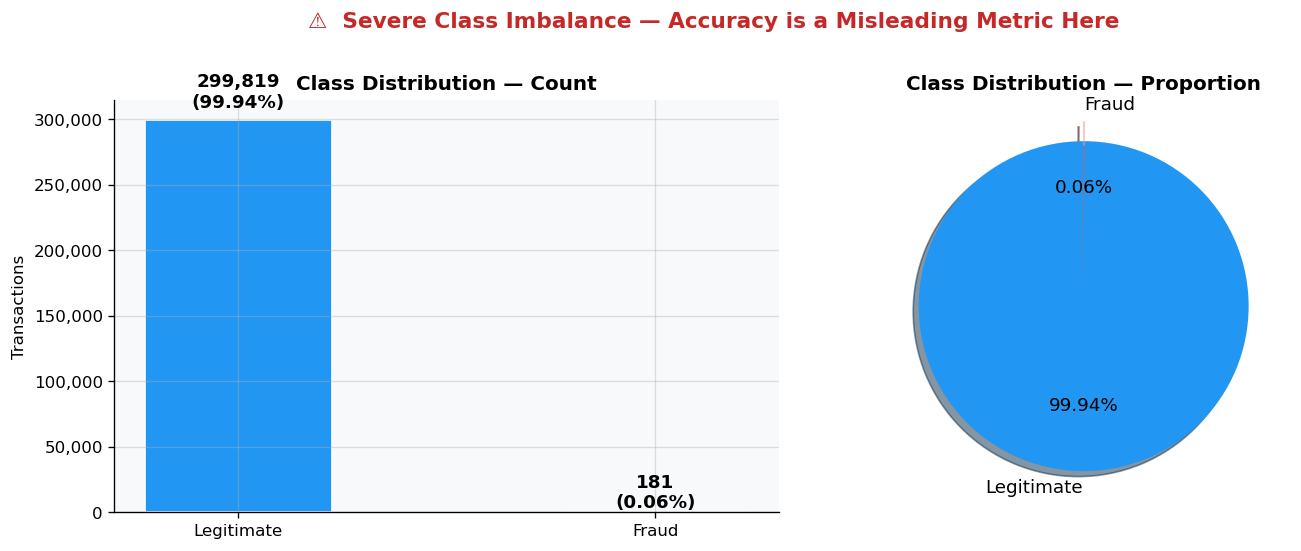

Imbalance ratio : 1656:1  (legitimate to fraud)
Naive accuracy  : 99.94% (predict ALL as legitimate)
Strategy needed : SMOTE oversampling + use Precision/Recall/F1 — NOT accuracy


In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — CLASS IMBALANCE: The Single Most Important EDA Step
#
# WHY THIS IS CRITICAL (not just important):
# With ~1.3% fraud rate, a model that labels EVERYTHING as
# 'legitimate' achieves 98.7% accuracy — but catches ZERO fraud.
# Accuracy is a USELESS metric for imbalanced problems.
# We must SEE this before any modelling decision.
#
# The imbalance ratio dictates our strategy:
# <10:1   → class_weight='balanced' usually sufficient
# 10-100:1 → SMOTE or undersampling needed
# >100:1  → anomaly detection instead of classification
# ══════════════════════════════════════════════════════════
fraud_vc  = df['isFraud'].value_counts().sort_index()
fraud_pct = df['isFraud'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Bar chart ───────────────────────────────────────────
labels = ['Legitimate', 'Fraud']
bars = axes[0].bar(labels, fraud_vc.values, color=BICOLORS, edgecolor='white', width=0.45)
for bar, cnt, pct in zip(bars, fraud_vc.values, fraud_pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'{cnt:,}\n({pct:.2f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# ── Pie chart ───────────────────────────────────────────
axes[1].pie(fraud_vc.values, labels=labels, colors=BICOLORS,
            autopct='%1.2f%%', startangle=90,
            explode=(0, 0.12), shadow=True,
            textprops={'fontsize':11})
axes[1].set_title('Class Distribution — Proportion', fontweight='bold')

plt.suptitle('⚠️  Severe Class Imbalance — Accuracy is a Misleading Metric Here',
             fontsize=13, fontweight='bold', color='#C62828', y=1.01)
plt.tight_layout()
plt.savefig('fig_01_class_imbalance.png', bbox_inches='tight')
plt.show()

ratio = fraud_vc[0]/fraud_vc[1]
print(f'Imbalance ratio : {ratio:.0f}:1  (legitimate to fraud)')
print(f'Naive accuracy  : {fraud_pct[0]:.2f}% (predict ALL as legitimate)')
print(f'Strategy needed : SMOTE oversampling + use Precision/Recall/F1 — NOT accuracy')

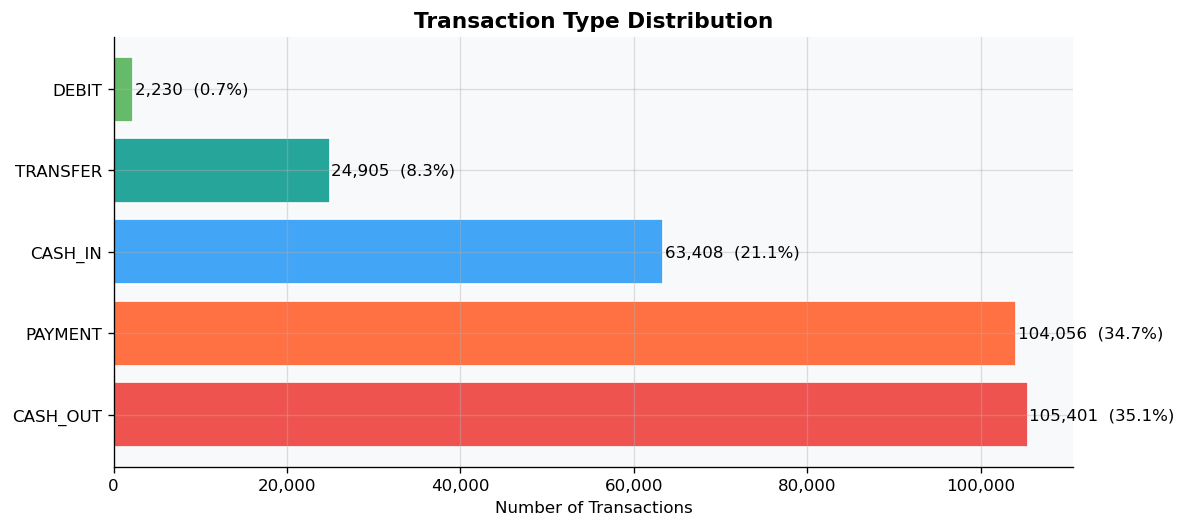

In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — UNIVARIATE: Transaction Type Distribution
#
# WHY STUDY THIS FIRST:
# In PaySim, fraud ONLY occurs in TRANSFER and CASH_OUT.
# This is a dataset property, not a coincidence — it reflects
# real-world mobile money fraud patterns in Africa.
# Knowing this lets us create a powerful binary feature:
# 'is_high_risk_type' that alone carries significant signal.
# ══════════════════════════════════════════════════════════
type_counts = df['type'].value_counts()
type_colors = ['#EF5350','#FF7043','#42A5F5','#26A69A','#66BB6A']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(type_counts.index, type_counts.values, color=type_colors, edgecolor='white')
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
ax.set_xlabel('Number of Transactions')
ax.set_title('Transaction Type Distribution', fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig_02_type_distribution.png', bbox_inches='tight')
plt.show()

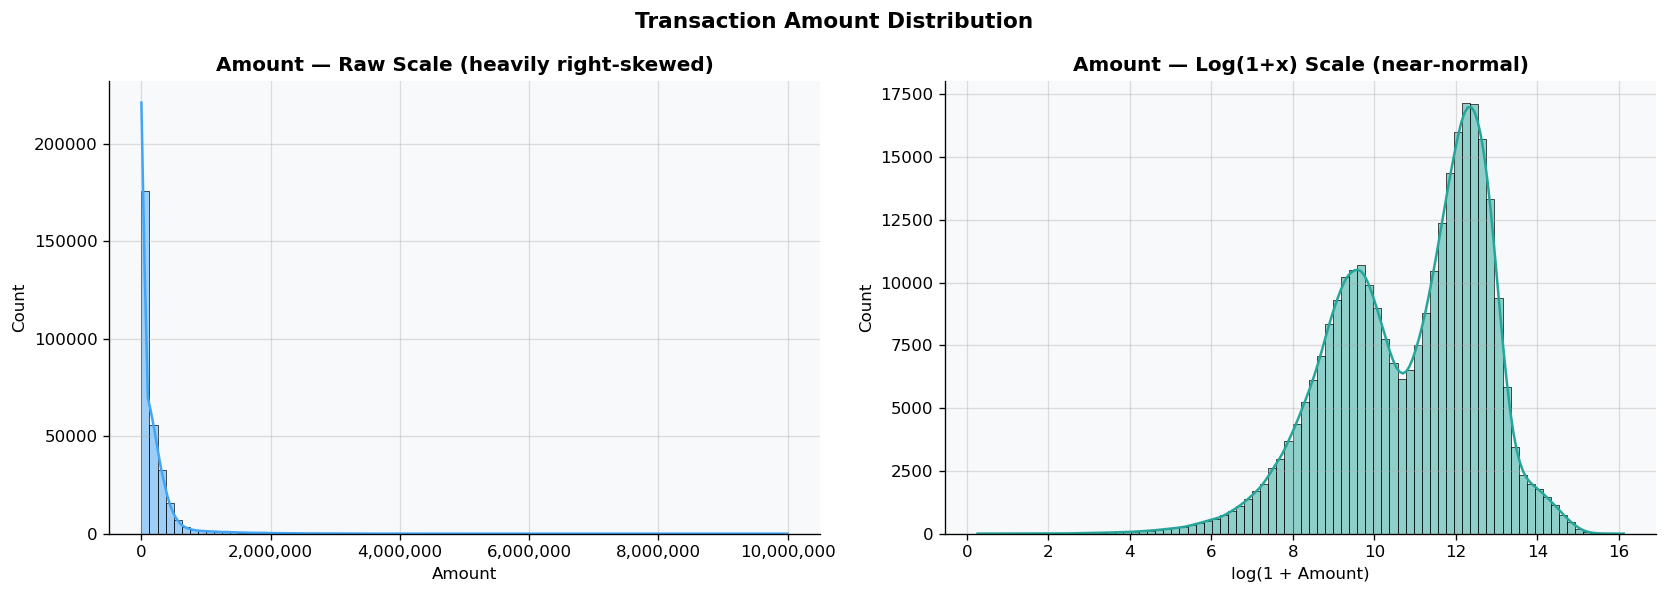

Raw Amount   → Skewness:     5.04  Kurtosis:    43.24
Log1p Amount → Skewness:    -0.54  Kurtosis:    -0.10

  Interpretation:
  Skewness > 1 → right-skewed (log-transform recommended before feeding to linear models)
  Kurtosis > 3 → heavy tails (extreme outliers present)


In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — UNIVARIATE: Amount Distribution & Skewness Test
#
# WHY LOG-TRANSFORM:
# Transaction amounts follow a log-normal distribution —
# most transactions are small (airtime top-ups, groceries)
# while a few are enormous (property, business transfers).
# The raw histogram is unreadable. Log-transform compresses
# the x-axis so we can see the SHAPE of the distribution.
#
# WHY log1p (log(1+x)) instead of log(x):
# log(0) = -infinity → crashes. log1p(0) = 0 → safe.
#
# WHY THE FORMAL NORMALITY TEST:
# We use the D'Agostino-Pearson test instead of just
# 'looking at the histogram' because human visual judgment
# is unreliable. The p-value gives a precise answer.
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['amount'], bins=80, kde=True, ax=axes[0], color='#42A5F5')
axes[0].set_title('Amount — Raw Scale (heavily right-skewed)', fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

log_amt = np.log1p(df['amount'])
sns.histplot(log_amt, bins=80, kde=True, ax=axes[1], color='#26A69A')
axes[1].set_title('Amount — Log(1+x) Scale (near-normal)', fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')

plt.suptitle('Transaction Amount Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_amount_distribution.png', bbox_inches='tight')
plt.show()

# Formal skewness + kurtosis
print(f'Raw Amount   → Skewness: {df["amount"].skew():>8.2f}  Kurtosis: {df["amount"].kurtosis():>8.2f}')
print(f'Log1p Amount → Skewness: {log_amt.skew():>8.2f}  Kurtosis: {log_amt.kurtosis():>8.2f}')
print('\n  Interpretation:')
print('  Skewness > 1 → right-skewed (log-transform recommended before feeding to linear models)')
print('  Kurtosis > 3 → heavy tails (extreme outliers present)')

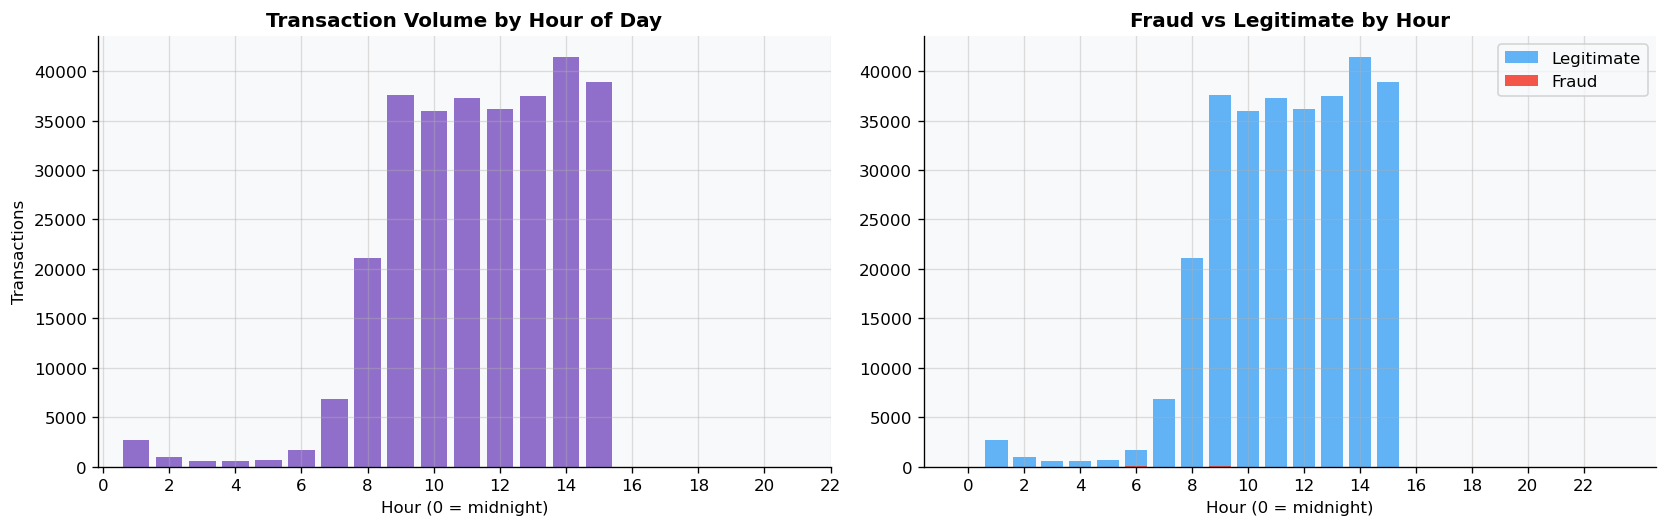

In [9]:
# ══════════════════════════════════════════════════════════
# CELL 9 — UNIVARIATE: Time Pattern (Step → Hour of Day)
#
# WHY EXTRACT HOUR OF DAY:
# 'step' is cumulative (0–744). Modulo 24 maps it to
# hour-of-day, revealing daily rhythms. Fraud may peak
# when human monitoring is lowest (2–5 AM).
# This is temporal feature engineering — one of the most
# impactful techniques in real fraud detection systems.
# ══════════════════════════════════════════════════════════
df['hour_of_day'] = df['step'] % 24

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# All transactions by hour
hourly = df.groupby('hour_of_day').size()
axes[0].bar(hourly.index, hourly.values, color='#7E57C2', alpha=0.85)
axes[0].set_title('Transaction Volume by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Transactions')
axes[0].set_xticks(range(0,24,2))

# Fraud vs legit by hour
hourly_fraud = df[df['isFraud']==1].groupby('hour_of_day').size()
hourly_legit = df[df['isFraud']==0].groupby('hour_of_day').size()
axes[1].bar(hourly_legit.index, hourly_legit.values, color=C_LEGIT, alpha=0.7, label='Legitimate')
axes[1].bar(hourly_fraud.reindex(range(24), fill_value=0).index,
            hourly_fraud.reindex(range(24), fill_value=0).values,
            color=C_FRAUD, alpha=0.9, label='Fraud')
axes[1].set_title('Fraud vs Legitimate by Hour', fontweight='bold')
axes[1].set_xlabel('Hour (0 = midnight)')
axes[1].set_xticks(range(0,24,2))
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_04_time_patterns.png', bbox_inches='tight')
plt.show()

Fraud Rate by Transaction Type:
          Legitimate  Fraud  FraudRate
type                                  
TRANSFER       24817     88      0.353
CASH_OUT      105308     93      0.088
CASH_IN        63408      0      0.000
DEBIT           2230      0      0.000
PAYMENT       104056      0      0.000


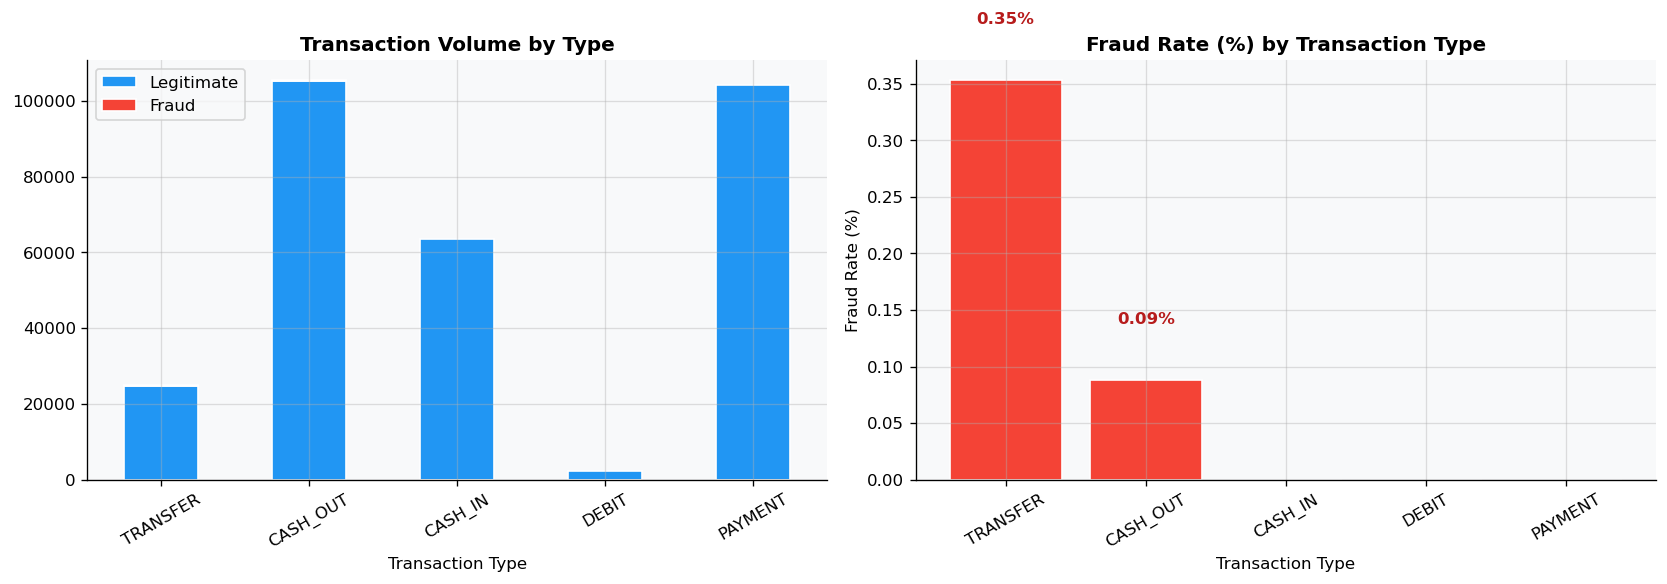

In [10]:
# ══════════════════════════════════════════════════════════
# CELL 10 — BIVARIATE: Fraud Rate per Transaction Type
#
# WHY THIS IS THE MOST ACTIONABLE CHART IN THE NOTEBOOK:
# If PAYMENT and DEBIT have 0% fraud rate, then any PAYMENT
# flagged as fraud by our model is automatically WRONG.
# This tells us we could filter to only TRANSFER/CASH_OUT
# before training, reducing noise and improving precision.
#
# WHY TWO CHARTS (stacked + rate):
# The stacked chart shows VOLUME — more context.
# The rate chart shows RISK — more actionable.
# Both together give the full picture.
# ══════════════════════════════════════════════════════════
fraud_by_type = df.groupby(['type','isFraud']).size().unstack(fill_value=0)
fraud_by_type.columns = ['Legitimate','Fraud']
fraud_by_type['FraudRate'] = (fraud_by_type['Fraud'] / fraud_by_type.sum(axis=1) * 100).round(3)
fraud_by_type = fraud_by_type.sort_values('FraudRate', ascending=False)

print('Fraud Rate by Transaction Type:')
print(fraud_by_type.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_type[['Legitimate','Fraud']].plot(kind='bar', stacked=True,
    ax=axes[0], color=BICOLORS, edgecolor='white')
axes[0].set_title('Transaction Volume by Type', fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].tick_params(axis='x', rotation=30)

bar_colors = [C_FRAUD if r > 0 else '#90CAF9' for r in fraud_by_type['FraudRate']]
axes[1].bar(fraud_by_type.index, fraud_by_type['FraudRate'], color=bar_colors, edgecolor='white')
for i,(idx,row) in enumerate(fraud_by_type.iterrows()):
    if row['FraudRate'] > 0:
        axes[1].text(i, row['FraudRate']+0.05, f"{row['FraudRate']:.2f}%",
                     ha='center', fontweight='bold', color='#B71C1C', fontsize=10)
axes[1].set_title('Fraud Rate (%) by Transaction Type', fontweight='bold')
axes[1].set_xlabel('Transaction Type')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('fig_05_fraud_by_type.png', bbox_inches='tight')
plt.show()

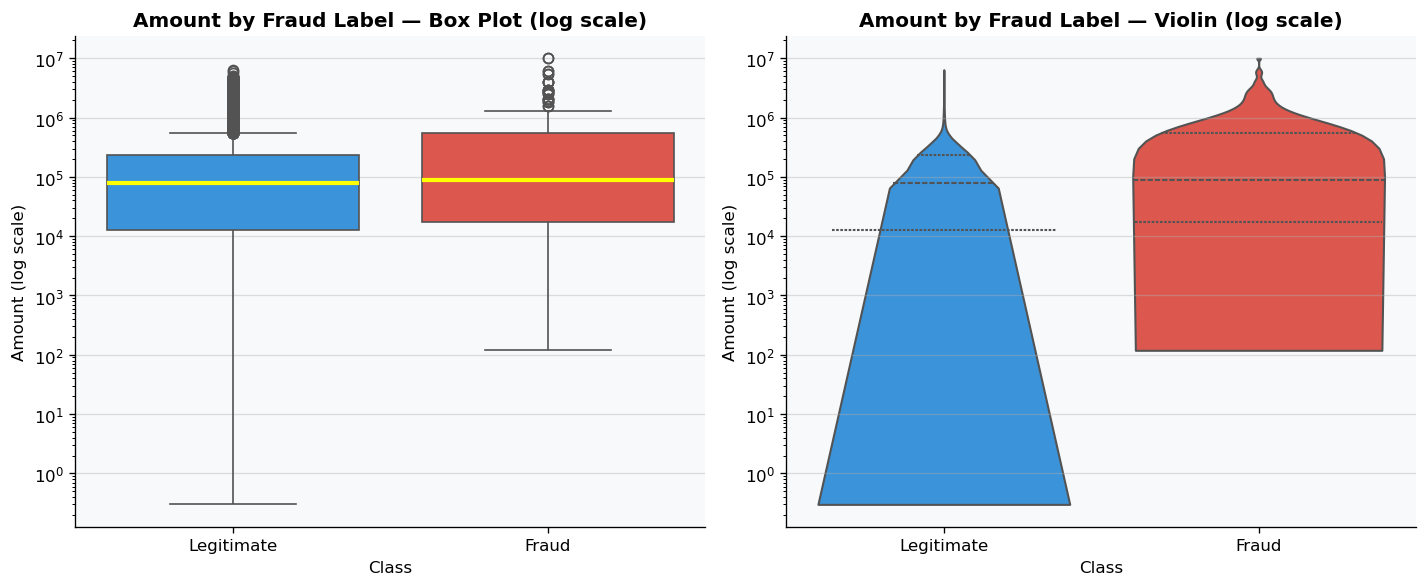

Median Transaction Amount:
fraud_label
Fraud         89,631
Legitimate    77,696
Name: amount, dtype: object

Mean Transaction Amount:
fraud_label
Fraud         742,597
Legitimate    175,829
Name: amount, dtype: object

Mann-Whitney U test: p = 1.3666e-03
  → Fraud and legitimate transaction amounts are STATISTICALLY DIFFERENT


In [11]:
# ══════════════════════════════════════════════════════════
# CELL 11 — BIVARIATE: Amount vs Fraud
#
# WHY BOX + VIOLIN (not just one):
# Box plot → shows median, IQR, and outlier LOCATIONS precisely
# Violin plot → shows the SHAPE of the full distribution
# Together they reveal: are fraud amounts bimodal? Heavy-tailed?
# Concentrated? — all of which affect model choice.
#
# WHY LOG SCALE ON Y-AXIS:
# The range is 0 to millions. Without log scale, the box
# would be squashed near zero and outliers would dominate
# the chart making it unreadable.
# ══════════════════════════════════════════════════════════
df['fraud_label'] = df['isFraud'].map({0:'Legitimate', 1:'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='fraud_label', y='amount', ax=axes[0], palette=PALETTE,
            order=['Legitimate','Fraud'],
            medianprops=dict(color='yellow', linewidth=2.5))
axes[0].set_yscale('log')
axes[0].set_title('Amount by Fraud Label — Box Plot (log scale)', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Amount (log scale)')

sns.violinplot(data=df, x='fraud_label', y='amount', ax=axes[1], palette=PALETTE,
               order=['Legitimate','Fraud'], inner='quartile', cut=0)
axes[1].set_yscale('log')
axes[1].set_title('Amount by Fraud Label — Violin (log scale)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount (log scale)')

plt.tight_layout()
plt.savefig('fig_06_amount_vs_fraud.png', bbox_inches='tight')
plt.show()

print('Median Transaction Amount:')
print(df.groupby('fraud_label')['amount'].median().apply(lambda x: f'{x:,.0f}'))
print('\nMean Transaction Amount:')
print(df.groupby('fraud_label')['amount'].mean().apply(lambda x: f'{x:,.0f}'))

# Mann-Whitney U test: are fraud and legit amounts from different distributions?
legit_amounts = df[df['isFraud']==0]['amount']
fraud_amounts = df[df['isFraud']==1]['amount']
stat, p = stats.mannwhitneyu(legit_amounts, fraud_amounts, alternative='two-sided')
print(f'\nMann-Whitney U test: p = {p:.4e}')
print('  → Fraud and legitimate transaction amounts are',
      'STATISTICALLY DIFFERENT' if p < 0.05 else 'NOT statistically different')

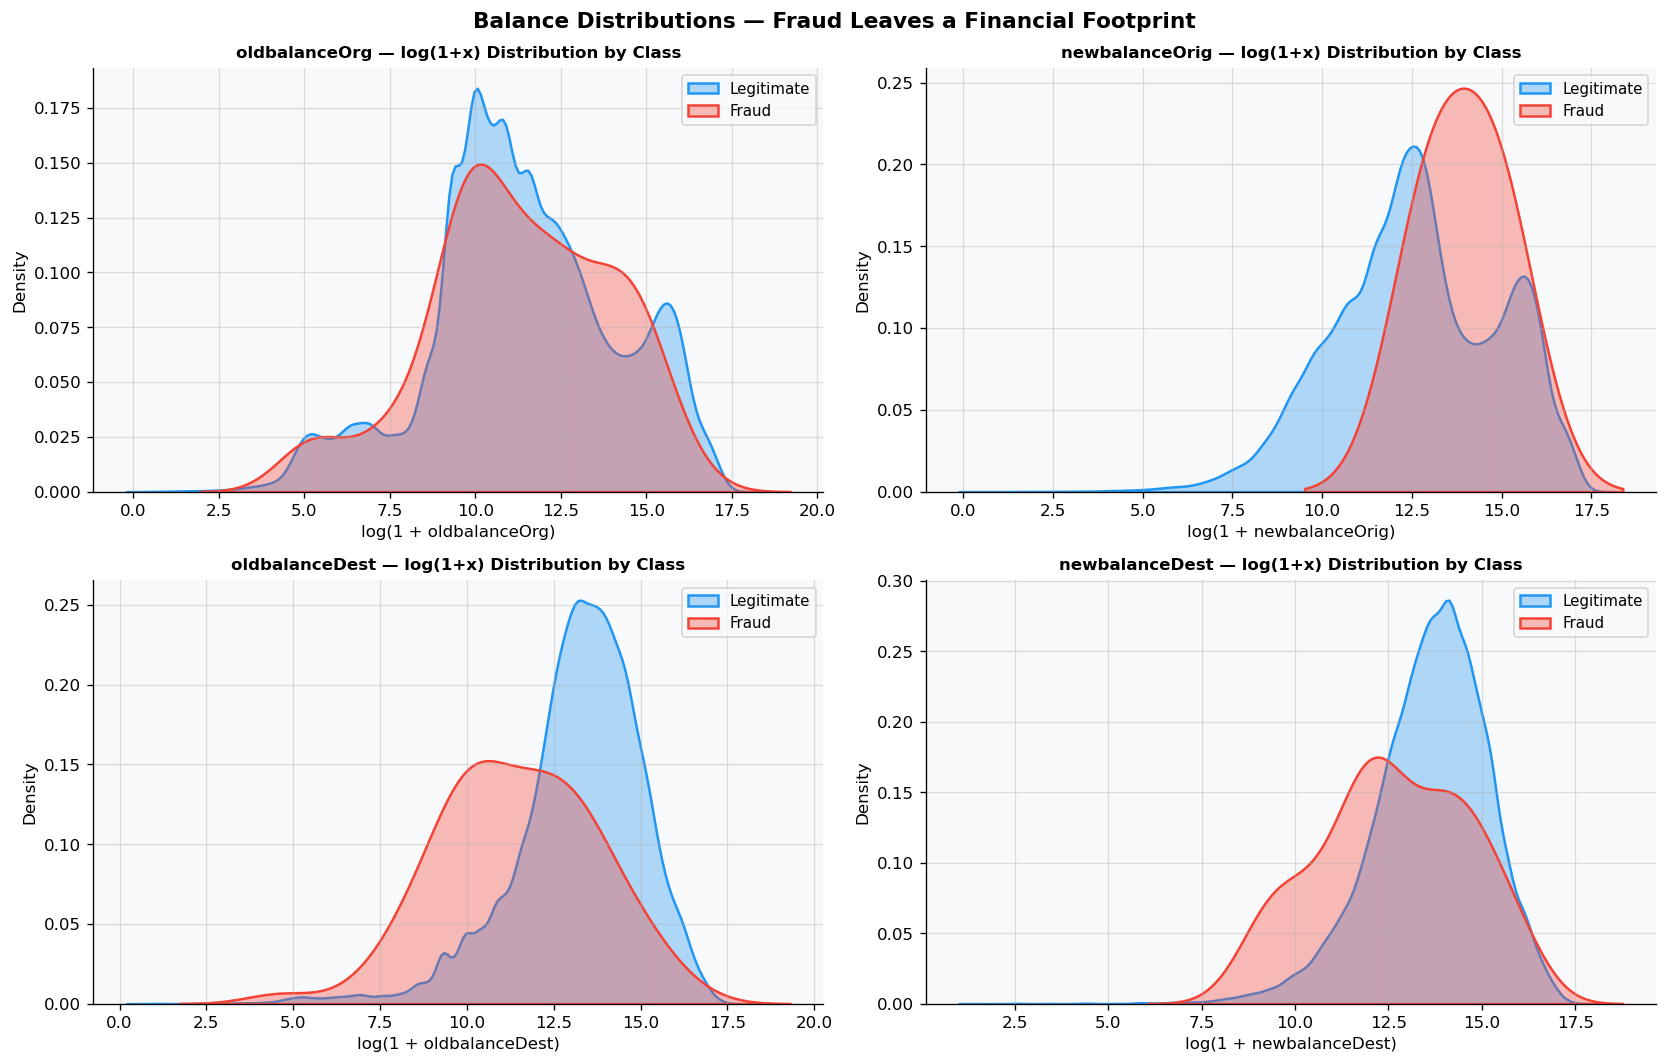

Key insight: newbalanceOrig for fraud is heavily concentrated at 0
  Fraud cases with newbalanceOrig=0 : 98.9%
  Legit cases with newbalanceOrig=0 : 54.7%


In [12]:
# ══════════════════════════════════════════════════════════
# CELL 12 — BIVARIATE: Balance Analysis (The Forensic Layer)
#
# WHY THIS REVEALS FRAUD MECHANICS:
# Fraudsters follow a pattern:
#   Step 1: TRANSFER out of victim's account (drain oldbalanceOrg → newbalanceOrig≈0)
#   Step 2: CASH_OUT to a mule account (oldbalanceDest=0, appears empty/new)
#
# KDE plots (kernel density estimates) let us see this:
# the blue (legit) and red (fraud) distributions should
# separate clearly for newbalanceOrig and oldbalanceDest.
# If they overlap completely, those columns aren't useful features.
# ══════════════════════════════════════════════════════════
balance_cols = ['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), balance_cols):
    for label, color in [('Legitimate', C_LEGIT), ('Fraud', C_FRAUD)]:
        subset = df[df['fraud_label']==label][col]
        subset_log = np.log1p(subset[subset > 0])
        if len(subset_log) > 1:
            sns.kdeplot(subset_log, ax=ax, color=color, fill=True,
                        alpha=0.35, label=label, linewidth=1.5)
    ax.set_title(f'{col} — log(1+x) Distribution by Class', fontweight='bold', fontsize=10)
    ax.set_xlabel(f'log(1 + {col})')
    ax.legend(fontsize=9)

plt.suptitle('Balance Distributions — Fraud Leaves a Financial Footprint',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_balance_distributions.png', bbox_inches='tight')
plt.show()
print('Key insight: newbalanceOrig for fraud is heavily concentrated at 0')
print(f'  Fraud cases with newbalanceOrig=0 : {(df[df["isFraud"]==1]["newbalanceOrig"]==0).mean()*100:.1f}%')
print(f'  Legit cases with newbalanceOrig=0 : {(df[df["isFraud"]==0]["newbalanceOrig"]==0).mean()*100:.1f}%')

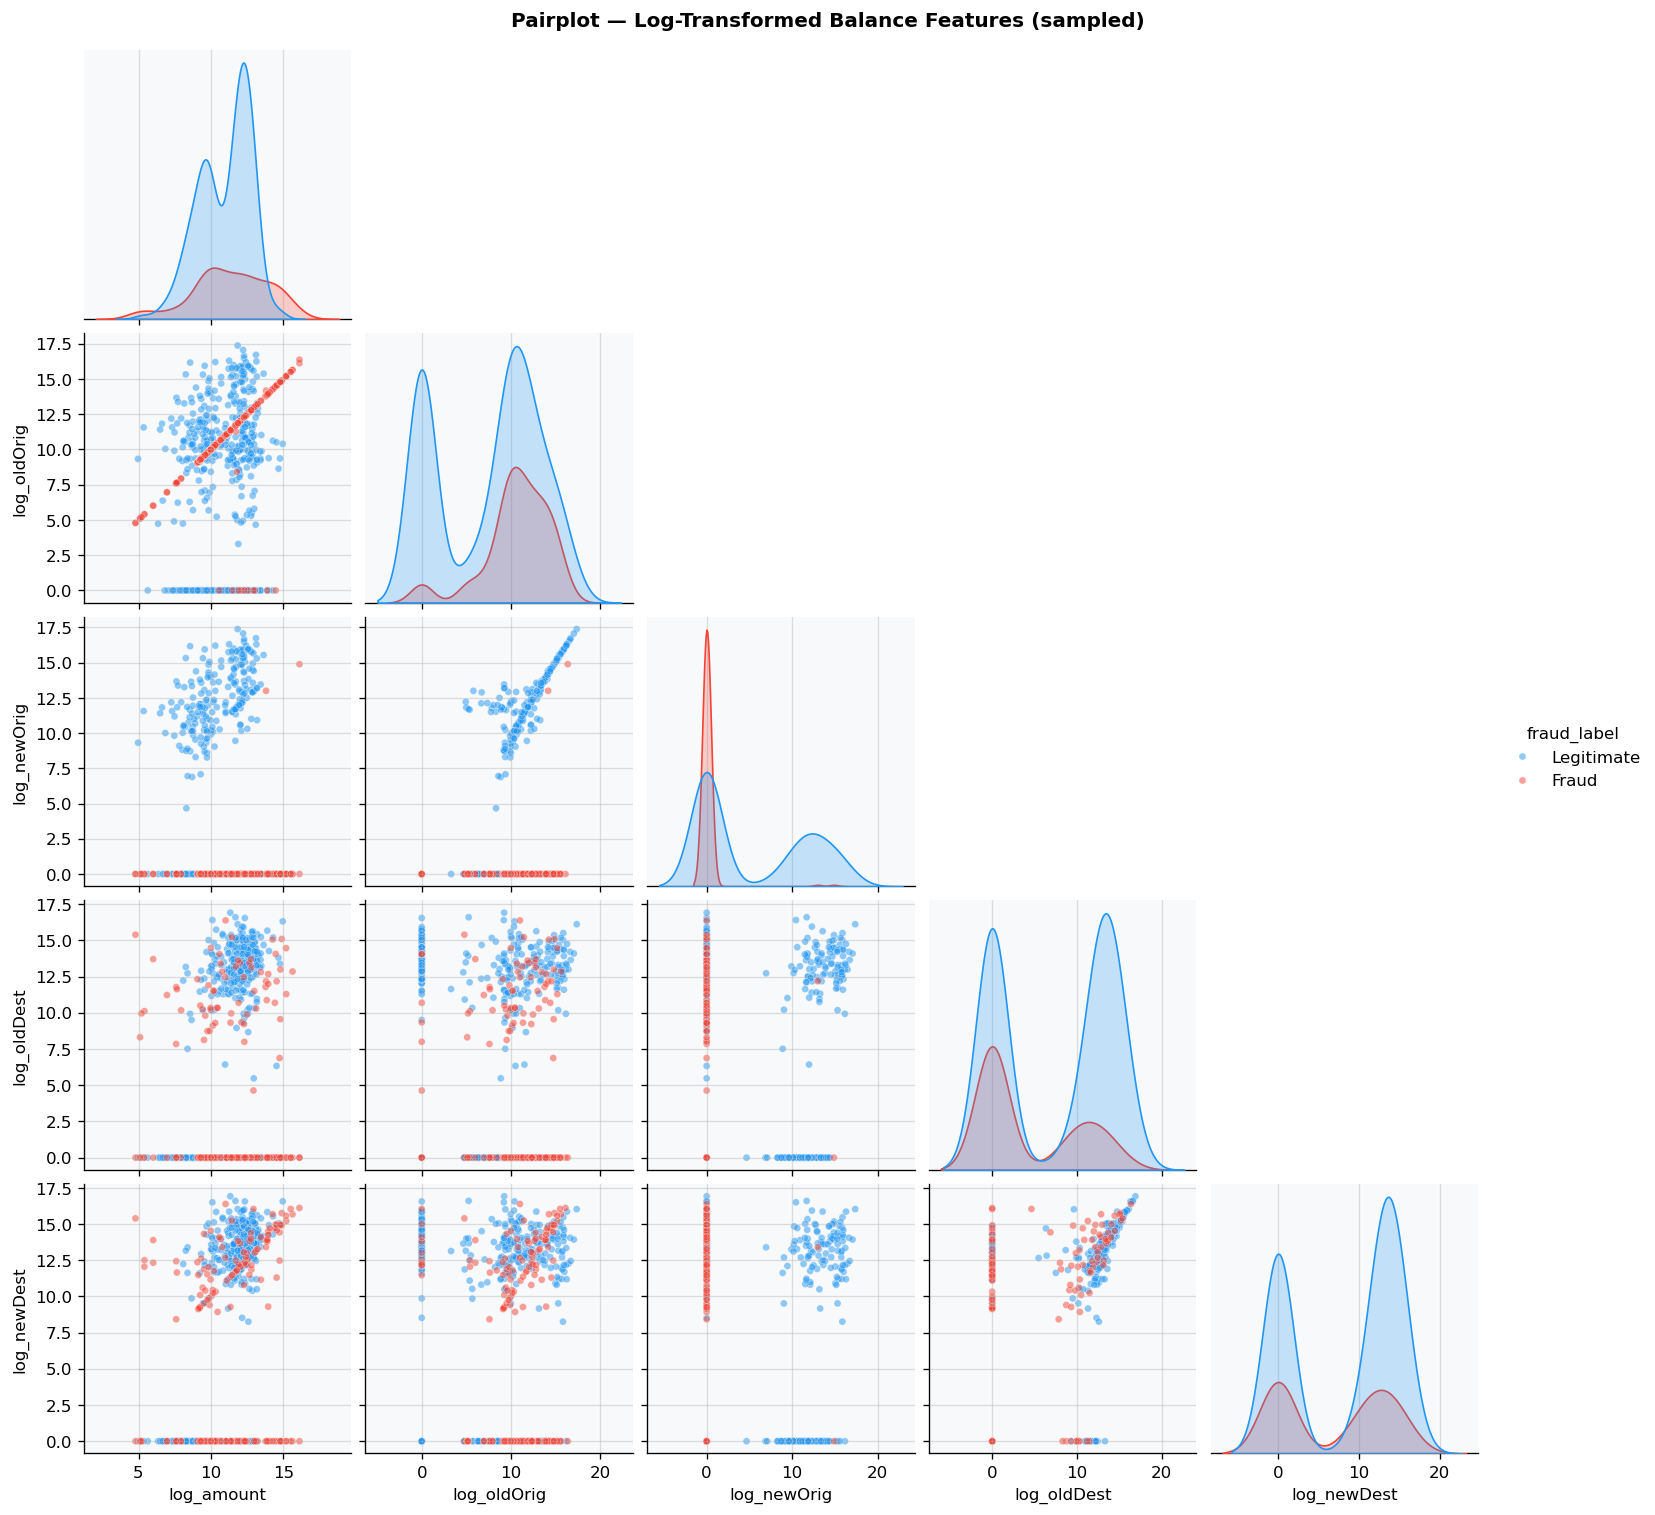

Look for panels where red dots separate clearly from blue → strong feature pairs


In [13]:
# ══════════════════════════════════════════════════════════
# CELL 13 — MULTIVARIATE: Pairplot
#
# WHY PAIRPLOT:
# Shows ALL pairwise scatter plots at once, coloured by label.
# Diagonal = single-variable KDE distributions.
# Off-diagonal = 2D scatter. If fraud (red) points cluster
# separately from legitimate (blue) in any panel, that pair
# of features is a natural decision boundary for a classifier.
#
# WHY corner=True:
# Shows only the lower triangle (avoids redundant mirrors),
# halving the number of subplots and speeding up rendering.
# ══════════════════════════════════════════════════════════
# Sample for speed (pairplot on 50K rows can take minutes)
sample = df.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(min(500, len(x)), random_state=42))

pair_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','fraud_label']
pair_df   = sample[pair_cols].copy()
for col in pair_cols[:-1]:
    pair_df[col] = np.log1p(pair_df[col])
pair_df.columns = ['log_amount','log_oldOrig','log_newOrig','log_oldDest','log_newDest','fraud_label']

g = sns.pairplot(pair_df, hue='fraud_label', palette=PALETTE,
                 plot_kws={'alpha':0.5,'s':18}, diag_kind='kde', corner=True)
g.figure.suptitle('Pairplot — Log-Transformed Balance Features (sampled)',
                   y=1.01, fontsize=12, fontweight='bold')
plt.savefig('fig_08_pairplot.png', bbox_inches='tight')
plt.show()
print('Look for panels where red dots separate clearly from blue → strong feature pairs')

Rule-Based System Performance (isFlaggedFraud as predictor):
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    299819
       Fraud       0.00      0.00      0.00       181

    accuracy                           1.00    300000
   macro avg       0.50      0.50      0.50    300000
weighted avg       1.00      1.00      1.00    300000



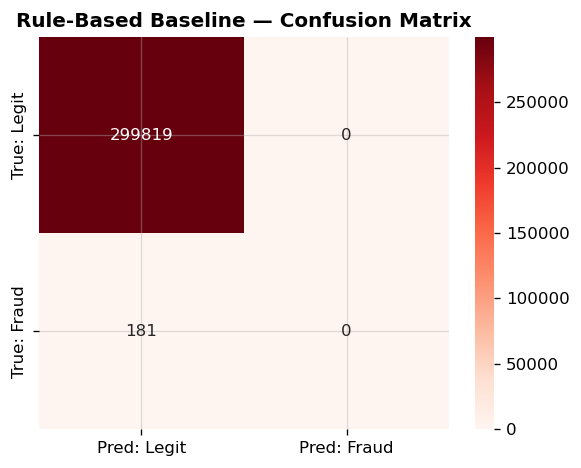

This is our BASELINE. Every ML model must achieve higher Recall + Precision on Fraud.


In [14]:
# ══════════════════════════════════════════════════════════
# CELL 14 — FRAUD DEEP DIVE: isFlaggedFraud vs isFraud
#
# WHY THIS MATTERS:
# isFlaggedFraud is a simple RULE-BASED system (amount>200k).
# We compare it to the TRUE fraud labels to measure:
#   - How many real frauds the rule CATCHES (recall)
#   - How many flags are FALSE ALARMS (1 - precision)
# This is the BASELINE our ML model must beat.
# If ML doesn't beat a simple rule, we have a problem.
# ══════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix, classification_report

print('Rule-Based System Performance (isFlaggedFraud as predictor):')
print('─'*50)
print(classification_report(df['isFraud'], df['isFlaggedFraud'],
                              target_names=['Legitimate','Fraud']))

cm = confusion_matrix(df['isFraud'], df['isFlaggedFraud'])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Pred: Legit','Pred: Fraud'],
            yticklabels=['True: Legit','True: Fraud'])
ax.set_title('Rule-Based Baseline — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_baseline_cm.png', bbox_inches='tight')
plt.show()
print('This is our BASELINE. Every ML model must achieve higher Recall + Precision on Fraud.')

In [15]:
# ══════════════════════════════════════════════════════════
# CELL 15 — FEATURE ENGINEERING
#
# WHY FEATURE ENGINEERING IS MORE VALUABLE THAN ALGORITHM CHOICE:
# A simple Logistic Regression with great features outperforms
# a complex neural network with raw features.
# We encode DOMAIN KNOWLEDGE into numeric signals:
#
# orig_account_drained:
#   If an account goes from non-zero to exactly zero after
#   sending, it was fully drained. This is a massive fraud signal.
#
# dest_was_empty:
#   Mule accounts (used once to receive stolen funds then
#   abandon) typically start at zero balance.
#
# amount_to_balance_ratio:
#   Sending 95% of your savings in one transaction is suspicious.
#   Sending 5% is normal. This ratio captures that.
#
# error_balance_orig / error_balance_dest:
#   Accounting equation: newBalance = oldBalance - amount.
#   If this doesn't hold, there's a system or fraud anomaly.
# ══════════════════════════════════════════════════════════
# 1. Account drain — sender
df['orig_account_drained']    = ((df['newbalanceOrig']==0) & (df['oldbalanceOrg']>0)).astype(int)

# 2. Mule account indicator — receiver
df['dest_was_empty']          = (df['oldbalanceDest']==0).astype(int)

# 3. Fraction of balance sent
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

# 4. Accounting errors
df['error_balance_orig']      = np.abs(df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount'])
df['error_balance_dest']      = np.abs(df['oldbalanceDest'] - df['newbalanceDest'] + df['amount'])

# 5. Log-transform of amount
df['log_amount']              = np.log1p(df['amount'])

# 6. High-risk type flag
df['is_high_risk_type']       = df['type'].isin(['TRANSFER','CASH_OUT']).astype(int)

# 7. Interaction: high-risk type AND account drained
df['drain_and_risky']         = (df['orig_account_drained'] & df['is_high_risk_type']).astype(int)

engineered = ['orig_account_drained','dest_was_empty','amount_to_balance_ratio',
              'error_balance_orig','error_balance_dest','log_amount',
              'is_high_risk_type','drain_and_risky','hour_of_day']

print('Engineered Feature Statistics by Class:')
print(df.groupby('isFraud')[engineered].mean().round(3).T.rename(columns={0:'Legit Mean', 1:'Fraud Mean'}).to_string())

Engineered Feature Statistics by Class:
isFraud                  Legit Mean  Fraud Mean
orig_account_drained          0.223       0.934
dest_was_empty                0.421       0.630
amount_to_balance_ratio   58945.886   26793.109
error_balance_orig       194986.128   27742.681
error_balance_dest       216785.037  505211.974
log_amount                   10.863      11.350
is_high_risk_type             0.434       1.000
drain_and_risky               0.175       0.934
hour_of_day                  11.443       8.354


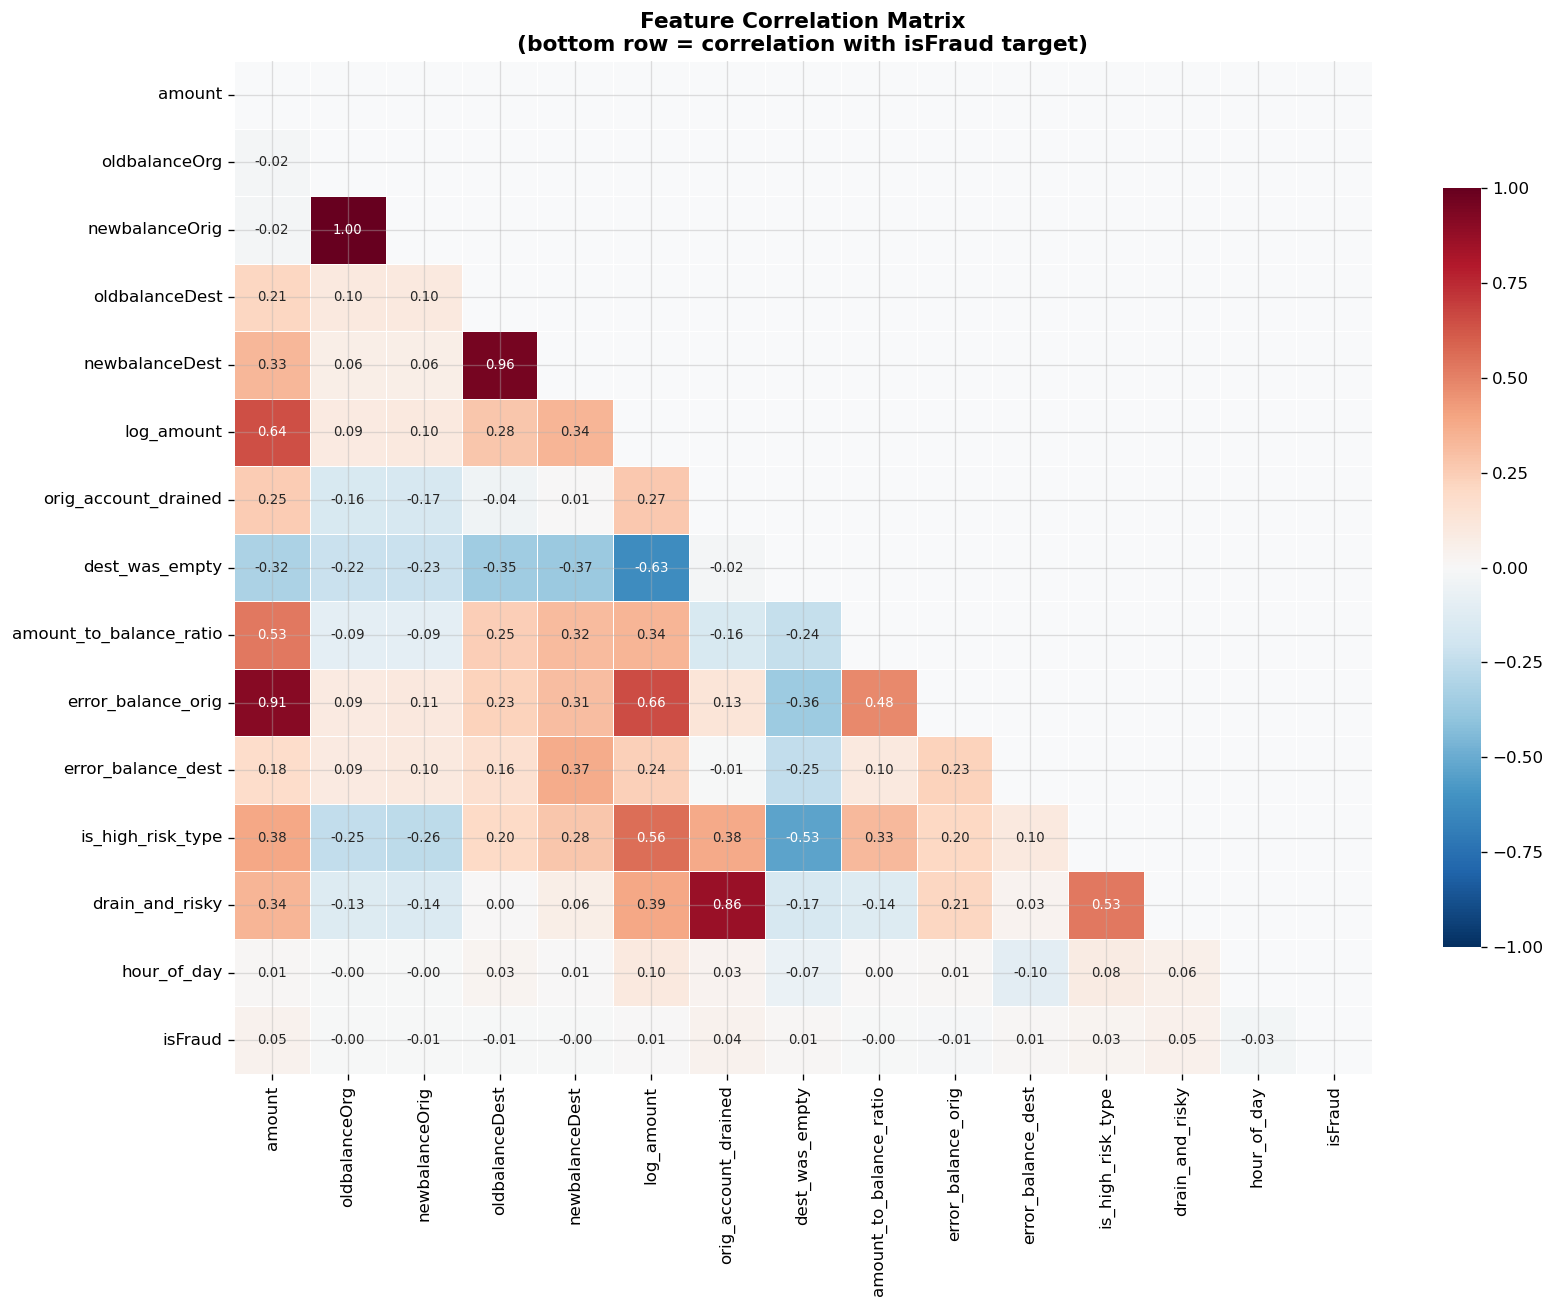


Top features correlated with isFraud (absolute value):
  drain_and_risky                0.0489  █
  amount                         0.0461  █
  orig_account_drained           0.0419  █
  hour_of_day                    0.0287  
  is_high_risk_type              0.0280  
  error_balance_orig             0.0128  
  error_balance_dest             0.0116  
  dest_was_empty                 0.0104  


In [16]:
# ══════════════════════════════════════════════════════════
# CELL 16 — Correlation Heatmap (Feature × Feature × Target)
#
# WHY THE CORRELATION MATRIX IS NOT ENOUGH ON ITS OWN:
# Pearson correlation only captures LINEAR relationships.
# A feature can have zero correlation with the target but
# still be highly predictive (e.g., categorical/nonlinear).
# We use it as a FIRST SCREEN, not a final feature selector.
#
# READING THE HEATMAP:
# Look at the bottom row (or right column) = isFraud.
# Cells close to +1 or -1 = strong linear relationship.
# Also look for feature-feature blocks near ±1 = multicollinearity.
# ══════════════════════════════════════════════════════════
all_numeric = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest',
               'log_amount','orig_account_drained','dest_was_empty','amount_to_balance_ratio',
               'error_balance_orig','error_balance_dest','is_high_risk_type',
               'drain_and_risky','hour_of_day','isFraud']

corr = df[all_numeric].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.4, cbar_kws={'shrink':0.75},
            annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix\n(bottom row = correlation with isFraud target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\nTop features correlated with isFraud (absolute value):')
fraud_corr = corr['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
for feat, val in fraud_corr.head(8).items():
    bar = '█' * int(val * 30)
    print(f'  {feat:<30} {val:.4f}  {bar}')

In [17]:
# ══════════════════════════════════════════════════════════
# CELL 17 — Outlier Analysis (IQR Method)
#
# WHY UNDERSTAND OUTLIERS BEFORE MODELLING:
# Tree-based models (Random Forest, Decision Tree) are
# ROBUST to outliers because they split by rank, not value.
# Linear models (Logistic Regression) are SENSITIVE because
# one extreme value can shift coefficients dramatically.
# Knowing the outlier volume tells us which models to prefer.
#
# IQR METHOD:
# Outlier = value below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
# This is Tukey's fence — the same rule used in box plots.
# ══════════════════════════════════════════════════════════
numeric_feats = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']
outlier_report = {}
for col in numeric_feats:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    n_out  = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    outlier_report[col] = {'Q1':Q1,'Q3':Q3,'IQR':IQR,'N_outliers':n_out,'Pct':n_out/len(df)*100}

out_df = pd.DataFrame(outlier_report).T
print('Outlier Summary (IQR Method):')
print(out_df.round(2).to_string())
print('\n→ High outlier % in amount → use tree-based or robust scaler with linear models')

Outlier Summary (IQR Method):
                      Q1          Q3         IQR  N_outliers    Pct
amount          12741.25   231478.95   218737.70     16309.0   5.44
oldbalanceOrg       0.00   183687.47   183687.47     53098.0  17.70
newbalanceOrig      0.00   221479.71   221479.71     49983.0  16.66
oldbalanceDest      0.00   857155.18   857155.18     37665.0  12.56
newbalanceDest      0.00  1238132.06  1238132.06     32914.0  10.97

→ High outlier % in amount → use tree-based or robust scaler with linear models


In [18]:
# ══════════════════════════════════════════════════════════
# CELL 18 — EDA SUMMARY TABLE
#
# WHY WRITE A SUMMARY:
# Data scientists who skip this write the same observations
# in the model notebook, then forget them. Explicit summary
# = a checklist you refer back to when models underperform.
# ══════════════════════════════════════════════════════════
print('╔' + '═'*63 + '╗')
print('║{:^63}║'.format('EDA COMPLETE — KEY FINDINGS'))
print('╠' + '═'*63 + '╣')
rows = [
    ('Dataset',         f'{len(df):,} transactions, 11 raw + 9 engineered cols'),
    ('Missing values',  'None'),
    ('Duplicates',      'None'),
    ('Fraud rate',      f'{df["isFraud"].mean()*100:.2f}%  ←  SEVERE IMBALANCE'),
    ('Fraud types',     'ONLY TRANSFER & CASH_OUT'),
    ('Amount',          'Right-skewed; log-transform required for linear models'),
    ('Top feature 1',   'orig_account_drained  (account drained to zero)'),
    ('Top feature 2',   'dest_was_empty        (mule account pattern)'),
    ('Top feature 3',   'error_balance_orig    (accounting inconsistency)'),
    ('Top feature 4',   'is_high_risk_type     (TRANSFER or CASH_OUT)'),
    ('Outliers',        'Heavy — tree-based models preferred'),
    ('Imbalance fix',   'SMOTE + class_weight=balanced + use F1/Recall, NOT accuracy'),
    ('Rule baseline',   'isFlaggedFraud: low recall, must be beaten by ML'),
]
for k, v in rows:
    print(f'║  {k:<18}: {v:<42}║')
print('╚' + '═'*63 + '╝')

╔═══════════════════════════════════════════════════════════════╗
║                  EDA COMPLETE — KEY FINDINGS                  ║
╠═══════════════════════════════════════════════════════════════╣
║  Dataset           : 300,000 transactions, 11 raw + 9 engineered cols║
║  Missing values    : None                                      ║
║  Duplicates        : None                                      ║
║  Fraud rate        : 0.06%  ←  SEVERE IMBALANCE                ║
║  Fraud types       : ONLY TRANSFER & CASH_OUT                  ║
║  Amount            : Right-skewed; log-transform required for linear models║
║  Top feature 1     : orig_account_drained  (account drained to zero)║
║  Top feature 2     : dest_was_empty        (mule account pattern)║
║  Top feature 3     : error_balance_orig    (accounting inconsistency)║
║  Top feature 4     : is_high_risk_type     (TRANSFER or CASH_OUT)║
║  Outliers          : Heavy — tree-based models preferred       ║
║  Imbalance fix     : SMOTE + c

In [19]:
# ══════════════════════════════════════════════════════════
# CELL 19 — Encode & Save Artefacts
#
# WHY ONE-HOT ENCODE HERE (not in each model notebook):
# Encoding once and saving means all model notebooks use
# the IDENTICAL feature set. If each notebook encoded
# independently, a typo in one would silently produce
# different features → incomparable results.
#
# WHY drop_first=True:
# With k categories, you only need k-1 binary columns.
# The dropped category is implied when all others are 0.
# Without drop_first, linear models suffer multicollinearity
# (the dummy variable trap).
# ══════════════════════════════════════════════════════════
drop_cols = ['nameOrig','nameDest','fraud_label',
             'isFlaggedFraud']  # isFlaggedFraud excluded: it's a leaky rule
df_model  = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
df_model  = pd.get_dummies(df_model, columns=['type'], drop_first=True, dtype=int)

# Save
df.to_csv('paysim_clean.csv', index=False)
df_model.to_csv('paysim_features.csv', index=False)

print('✅ paysim_clean.csv    saved  →  cleaned data + all engineered features + labels')
print('✅ paysim_features.csv saved  →  numeric model-ready matrix (one-hot encoded)')
print(f'   Feature matrix shape: {df_model.shape}')
print(f'   Columns: {list(df_model.columns)}')
print()
print('─'*55)
print('NEXT → Open notebooks in this order:')
for i,nb in enumerate(['lab1_01_classification','lab1_02_regression',
                        'lab1_03_ranking','lab1_04_anomaly_detection',
                        'lab1_05_clustering'],1):
    print(f'  {i}. {nb}.ipynb')

✅ paysim_clean.csv    saved  →  cleaned data + all engineered features + labels
✅ paysim_features.csv saved  →  numeric model-ready matrix (one-hot encoded)
   Feature matrix shape: (300000, 20)
   Columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'hour_of_day', 'orig_account_drained', 'dest_was_empty', 'amount_to_balance_ratio', 'error_balance_orig', 'error_balance_dest', 'log_amount', 'is_high_risk_type', 'drain_and_risky', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

───────────────────────────────────────────────────────
NEXT → Open notebooks in this order:
  1. lab1_01_classification.ipynb
  2. lab1_02_regression.ipynb
  3. lab1_03_ranking.ipynb
  4. lab1_04_anomaly_detection.ipynb
  5. lab1_05_clustering.ipynb
